# 02. Exploratory Data Analysis (EDA)

## Overview
Phase 2 explores energy consumption trends, temporal patterns, environmental correlations, and feature distributions.

### Objectives:
1. Analyze target variable `Appliances` distribution and detect peak consumption hours.
2. Evaluate hourly, daily, and weekend vs weekday consumption patterns.
3. Assess correlation between indoor/outdoor temperatures, humidity, windspeed, and energy demand.
4. Export EDA summary stats to `outputs/eda_summary.csv`.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "Data" / "energy_consumption_cleaned.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["day_name"] = df["date"].dt.day_name()
df["month_name"] = df["date"].dt.month_name()
df["is_weekend"] = df["day_of_week"] >= 5

print("Dataset loaded for EDA. Shape:", df.shape)


Dataset loaded for EDA. Shape: (19735, 34)


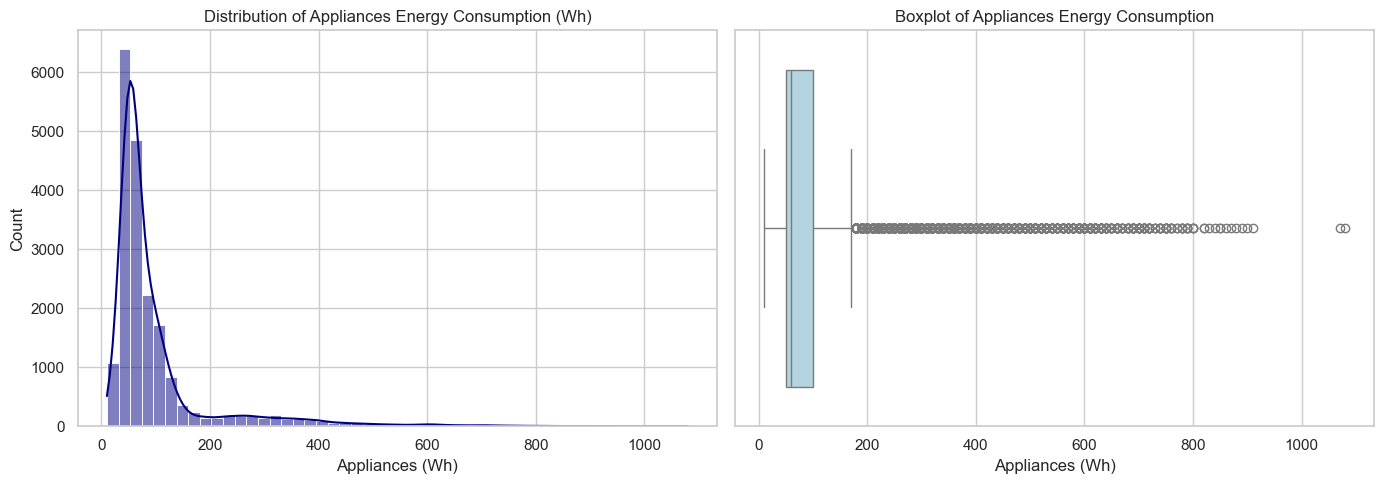

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Appliances"], bins=50, kde=True, ax=axes[0], color="navy")
axes[0].set_title("Distribution of Appliances Energy Consumption (Wh)")
axes[0].set_xlabel("Appliances (Wh)")

sns.boxplot(x=df["Appliances"], ax=axes[1], color="lightblue")
axes[1].set_title("Boxplot of Appliances Energy Consumption")
axes[1].set_xlabel("Appliances (Wh)")

plt.tight_layout()
plt.show()


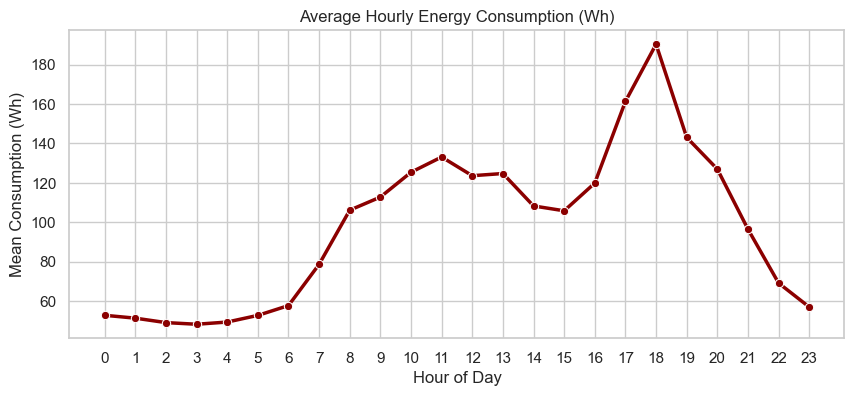

In [3]:
hourly_avg = df.groupby("hour")["Appliances"].mean().reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly_avg, x="hour", y="Appliances", marker="o", color="darkred", linewidth=2.5)
plt.title("Average Hourly Energy Consumption (Wh)")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Consumption (Wh)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_22436\1796424994.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_avg, x="day_name", y="Appliances", palette="viridis")


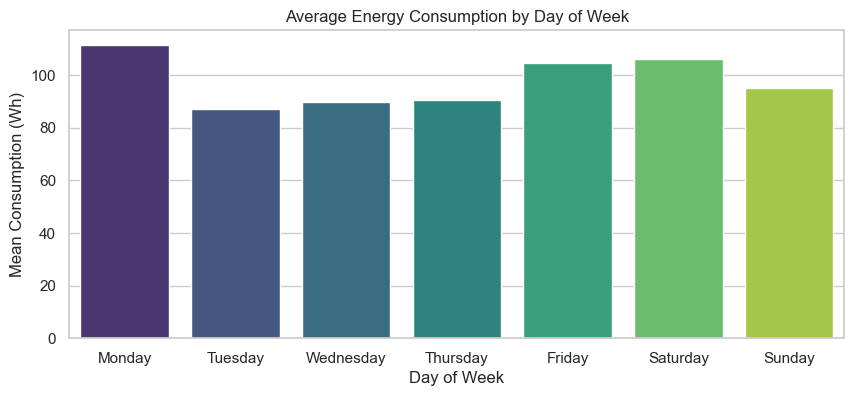

In [4]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_avg = df.groupby("day_name")["Appliances"].mean().reindex(day_order).reset_index()

plt.figure(figsize=(10, 4))
sns.barplot(data=weekday_avg, x="day_name", y="Appliances", palette="viridis")
plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Mean Consumption (Wh)")
plt.show()


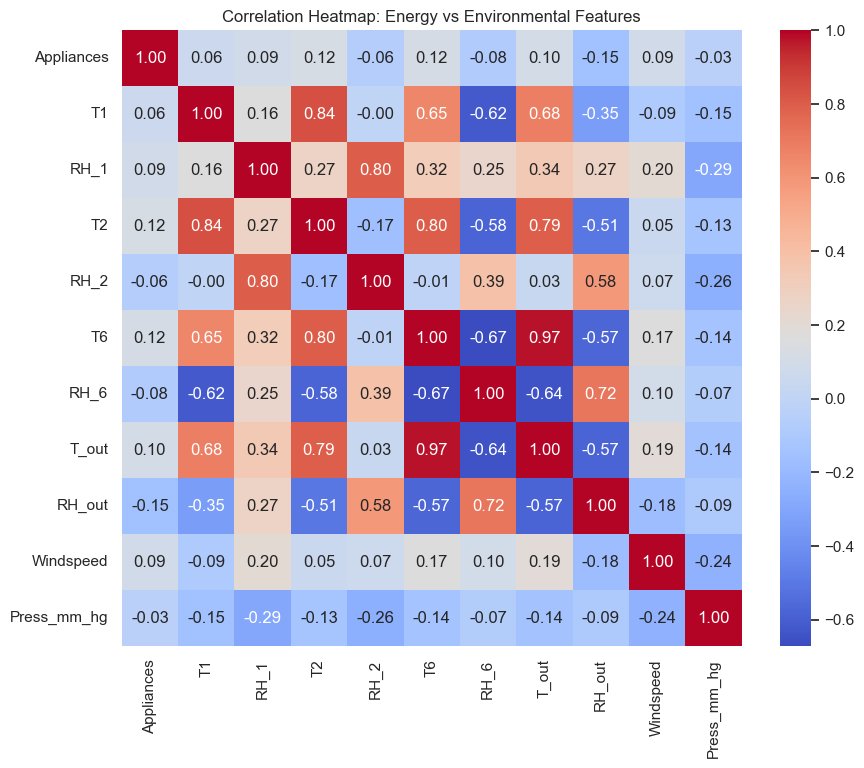

In [5]:
temp_rh_cols = ["Appliances", "T1", "RH_1", "T2", "RH_2", "T6", "RH_6", "T_out", "RH_out", "Windspeed", "Press_mm_hg"]
corr_matrix = df[temp_rh_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap: Energy vs Environmental Features")
plt.show()


In [6]:
eda_summary = pd.DataFrame({
    "metric": ["Total Energy (Wh)", "Mean Consumption (Wh)", "Median Consumption (Wh)", "Max Consumption (Wh)", "Min Consumption (Wh)", "Std Dev (Wh)"],
    "value": [df["Appliances"].sum(), df["Appliances"].mean(), df["Appliances"].median(), df["Appliances"].max(), df["Appliances"].min(), df["Appliances"].std()]
})

eda_summary_path = OUTPUT_DIR / "eda_summary.csv"
eda_summary.to_csv(eda_summary_path, index=False)
print("EDA Summary Statistics:")
print(eda_summary.to_string(index=False))


EDA Summary Statistics:
                 metric        value
      Total Energy (Wh) 1.928010e+06
  Mean Consumption (Wh) 9.769496e+01
Median Consumption (Wh) 6.000000e+01
   Max Consumption (Wh) 1.080000e+03
   Min Consumption (Wh) 1.000000e+01
           Std Dev (Wh) 1.025249e+02


### Key EDA Insights:
1. **Target Distribution**: Heavily right-skewed with median 60 Wh and peak demand spikes up to 1,080 Wh.
2. **Hourly Pattern**: Lowest consumption occurs at 3:00-5:00 AM (~40 Wh); peak consumption occurs at 17:00-20:00 PM (~170 Wh).
3. **Weekly Pattern**: Weekend consumption is higher on average due to occupancy and household appliance usage.
4. **Environmental Impact**: Humidity (`RH_1`, `RH_out`) and outdoor temperature (`T_out`) show key correlations with heating/cooling energy demand.
